# Philippine Eagle Conservation Analytics
## Literature-benchmarked synthetic data, demographic modelling, habitat risk, and conservation genomics

This reproducible notebook builds a **fully synthetic** Philippine eagle (*Pithecophaga jefferyi*) dataset calibrated to peer-reviewed numerical benchmarks. It is intended for conservation-method development, teaching, and transparent scenario analysis.

> **Safeguard:** No real nest locations, telemetry coordinates, identities, or genotypes are included. Synthetic records must never be interpreted as observations of actual eagles.

### Questions addressed

- Does the synthetic dataset reproduce published population, movement, breeding, forest-loss, and genomic benchmarks?
- Which ecological pressures are associated with simulated reproductive failure?
- How do alternative protection scenarios alter area of habitat and long-term population trajectories?
- How can genomic diversity inform pairing and lineage-management logic?
- Which territories and interventions emerge as priorities under a limited illustrative budget?

In [2]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.special import expit
from scipy.stats import spearmanr
from scipy.optimize import linear_sum_assignment
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, brier_score_loss
from sklearn.calibration import calibration_curve
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from IPython.display import display, Markdown

warnings.filterwarnings('ignore')
SEED = 20260716
rng = np.random.default_rng(SEED)
OUT = Path('philippine_eagle_outputs')
OUT.mkdir(exist_ok=True)
plt.rcParams.update({
    'figure.figsize': (9.5, 5.8), 'figure.dpi': 110, 'savefig.dpi': 200,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titleweight': 'bold', 'axes.titlesize': 13,
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'legend.frameon': False
})
print('Seed:', SEED)
print('Output directory:', OUT.resolve())

Seed: 20260716
Output directory: /Users/petalc01/Philippine Eagle Conservation/philippine_eagle_outputs


## 1. Literature benchmark registry

The registry combines peer-reviewed sources discoverable through **PubMed**, **FAO AGRIS**, and journals represented in the **USDA AGRICOLA Journal Index**. Database coverage varies by discipline; the numerical benchmark always comes from the cited article itself.

In [4]:
benchmarks = pd.DataFrame([
 ['Population','Sutton et al., 2023, Animal Conservation','Breeding pairs',392,'pairs','318–447','10.1111/acv.12854','','','Yes'],
 ['Habitat','Sutton et al., 2023, Animal Conservation','Area of habitat',28624,'km²','modelled AOH','10.1111/acv.12854','','','Yes'],
 ['Habitat','Sutton et al., 2023, Animal Conservation','AOH protected',32,'%','reported coverage','10.1111/acv.12854','','','Yes'],
 ['Movement','Sutton et al., 2024, Ibis','Median 95% home range',68,'km²','CI 62–74, range 39–161','10.1111/ibi.13233','','','Yes'],
 ['Movement','Sutton et al., 2024, Ibis','Median 50% core range',13,'km²','CI 11–14, range 9–33','10.1111/ibi.13233','','','Yes'],
 ['Movement','Sutton et al., 2024, Ibis','Space-time outside core',79,'%','median','10.1111/ibi.13233','','','Yes'],
 ['Spacing','Bueser et al., 2003, Ibis','Nearest-neighbour distance',12.74,'km','mean','10.1046/j.1474-919X.2003.00131.x','','','Yes'],
 ['Breeding','Ibañez et al., 2003, Wilson Bulletin','Incubation duration',58,'days','observed nest','10.1676/01-054','','','Yes'],
 ['Breeding','Ibañez et al., 2003, Wilson Bulletin','Female incubation share',74,'%','observed time budget','10.1676/01-054','','','Yes'],
 ['Forest','Daipan, 2021, Journal of Threatened Taxa','KBA forest loss',14213,'ha/year','2001–2019 mean','10.11609/jott.6904.13.13.20019-20032','','',''],
 ['Forest','Perez et al., 2020, Forests','Sierra Madre net forest loss',17000,'ha','1,764,000 to 1,747,000 ha','10.3390/f11101071','','Yes','Yes'],
 ['Genomics','Bacus et al., 2025, Ecology and Evolution','Nucleotide diversity',0.00054,'π','±0.00030, n=32, 17 haplotypes','10.1002/ece3.72572','PMID 41356510','','Yes'],
 ['Genomics','Perdon et al., 2026, BMC Genomics','Genome-wide heterozygosity',0.000309,'proportion','minimum 0.000207, n=35','10.1186/s12864-026-12859-9','PMID 42010461','','Yes'],
 ['Identification','Ong et al., 2011, Molecular Ecology Resources','COI barcode reference',1,'study','Philippine accipitrids','10.1111/j.1755-0998.2010.02928.x','PMID 21429130','','']
], columns=['domain','study','metric','value','unit','uncertainty','doi','PubMed','AGRIS','AGRICOLA_journal'])
display(benchmarks)
benchmarks.to_csv(OUT/'literature_benchmarks.csv', index=False)

,domain,study,metric,value,unit,uncertainty,doi,PubMed,AGRIS,AGRICOLA_journal
0,Population,"Sutton et al., 2023, Animal Conservation",Breeding pairs,392.000000,pairs,318–447,10.1111/acv.12854,,,Yes
1,Habitat,"Sutton et al., 2023, Animal Conservation",Area of habitat,28624.000000,km²,modelled AOH,10.1111/acv.12854,,,Yes
2,Habitat,"Sutton et al., 2023, Animal Conservation",AOH protected,32.000000,%,reported coverage,10.1111/acv.12854,,,Yes
3,Movement,"Sutton et al., 2024, Ibis",Median 95% home range,68.000000,km²,"CI 62–74, range 39–161",10.1111/ibi.13233,,,Yes
4,Movement,"Sutton et al., 2024, Ibis",Median 50% core range,13.000000,km²,"CI 11–14, range 9–33",10.1111/ibi.13233,,,Yes
5,Movement,"Sutton et al., 2024, Ibis",Space-time outside core,79.000000,%,median,10.1111/ibi.13233,,,Yes
6,Spacing,"Bueser et al., 2003, Ibis",Nearest-neighbour distance,12.740000,km,mean,10.1046/j.1474-919X.2003.00131.x,,,Yes
7,Breeding,"Ibañez et al., 2003, Wilson Bulletin",Incubation duration,58.000000,days,observed nest,10.1676/01-054,,,Yes
8,Breeding,"Ibañez et al., 2003, Wilson Bulletin",Female incubation share,74.000000,%,observed time budget,10.1676/01-054,,,Yes
9,Forest,"Daipan, 2021, Journal of Threatened Taxa",KBA forest loss,14213.000000,ha/year,2001–2019 mean,10.11609/jott.6904.13.13.20019-20032,,,


## 2. Synthetic territories calibrated to population and movement ecology

The island allocation below is a **scenario allocation**, not an island census. It sums exactly to the published global estimate of 392 breeding pairs and 28,624 km² of modelled habitat.

In [6]:
island_plan = pd.DataFrame({
    'island':['Mindanao','Luzon','Samar','Leyte'],
    'pairs':[231,80,47,34],
    'aoh_km2':[16888,5725,3435,2576]
})
assert island_plan.pairs.sum()==392 and island_plan.aoh_km2.sum()==28624

records=[]
for _,r in island_plan.iterrows():
    n=int(r.pairs); island=r.island
    shift={'Mindanao':0.10,'Luzon':0.00,'Samar':-0.06,'Leyte':-0.10}[island]
    forest=np.clip(rng.beta(4.0+shift,2.5,n),0.05,0.99)
    fragment=np.clip(1-forest+rng.normal(0,0.10,n),0.01,0.99)
    pressure=np.clip(rng.beta(2.0,4.2,n)+0.34*fragment-0.08*shift,0.01,0.99)
    canopy=np.clip(0.75*forest+rng.normal(0.10,0.08,n),0.03,0.99)
    prey=np.clip(0.62*forest+0.22*(1-pressure)+rng.normal(0.05,0.09,n),0.02,0.99)
    road=np.clip(rng.gamma(2.2,4.5,n)*(1-0.55*pressure),0.1,45)
    persecution=np.clip(0.52*pressure+0.28*fragment+rng.normal(0.04,0.08,n),0.01,0.99)
    for i in range(n):
        records.append([f'{island[:2].upper()}-{i+1:03d}',island,forest[i],fragment[i],pressure[i],canopy[i],prey[i],road[i],persecution[i],r.aoh_km2/n])

territories=pd.DataFrame(records,columns=['territory_id','island','forest_integrity','fragmentation_index','human_pressure','canopy_integrity','prey_index','distance_to_road_km','persecution_risk','territory_aoh_km2'])

# Exactly 32% protected, with selection probability weighted toward better forest.
protection_score=0.55*territories.forest_integrity+0.25*(1-territories.human_pressure)+rng.normal(0,0.18,len(territories))
territories['protected']=False
territories.loc[protection_score.nlargest(round(0.32*len(territories))).index,'protected']=True

# Home-range and core-range calibration.
hr=np.exp(np.log(68)+0.45*territories.fragmentation_index+0.22*(1-territories.prey_index)+rng.normal(0,0.31,len(territories)))
hr*=68/np.median(hr)
territories['home_range_95_km2']=np.clip(hr,39,161)
territories['home_range_95_km2']*=68/territories.home_range_95_km2.median()
territories['home_range_95_km2']=territories.home_range_95_km2.clip(39,161)
core=territories.home_range_95_km2*np.clip(rng.normal(0.19,0.03,len(territories)),0.11,0.27)
core*=13/np.median(core)
territories['core_range_50_km2']=core.clip(9,33)
outside=100*(1-territories.core_range_50_km2/territories.home_range_95_km2)+rng.normal(0,1.8,len(territories))
outside+=79-np.median(outside)
territories['space_time_outside_core_pct']=outside.clip(60,91)
spacing=rng.lognormal(np.log(12.74),0.27,len(territories))
territories['nearest_neighbour_km']=spacing*12.74/spacing.mean()

risk=(0.27*territories.fragmentation_index+0.24*territories.human_pressure+0.19*territories.persecution_risk+0.13*(1-territories.prey_index)+0.10*(1-territories.canopy_integrity)+0.07*(~territories.protected).astype(float))
territories['risk_score']=100*(risk-risk.min())/(risk.max()-risk.min())
territories['risk_class']=pd.cut(territories.risk_score,[-0.1,35,55,75,100.1],labels=['Low','Moderate','High','Critical'])
territories.head()

,territory_id,island,forest_integrity,fragmentation_index,human_pressure,canopy_integrity,prey_index,distance_to_road_km,persecution_risk,territory_aoh_km2,protected,home_range_95_km2,core_range_50_km2,space_time_outside_core_pct,nearest_neighbour_km,risk_score,risk_class
0,MI-001,Mindanao,0.383566,0.614481,0.487054,0.330757,0.580989,1.067982,0.434486,73.108225,False,151.091757,33.000000,75.581665,12.633939,55.650106,High
1,MI-002,Mindanao,0.776536,0.247871,0.285801,0.824310,0.924626,14.135593,0.181997,73.108225,True,116.670514,23.178809,78.349856,10.860706,11.835073,Low
2,MI-003,Mindanao,0.899139,0.151337,0.350737,0.681823,0.688789,9.630695,0.231566,73.108225,True,42.372033,9.000000,76.979380,12.345954,17.182111,Low
3,MI-004,Mindanao,0.688331,0.296625,0.329703,0.680411,0.398658,10.701906,0.296758,73.108225,True,55.720312,13.919482,74.630393,14.436439,27.477667,Low
4,MI-005,Mindanao,0.527496,0.571075,0.684289,0.564988,0.375861,1.753753,0.650153,73.108225,False,80.486608,15.276954,78.939679,11.680369,65.386256,High


In [7]:
validation=pd.DataFrame([
 ['Breeding pairs',392,len(territories),'pairs'],
 ['Area of habitat',28624,island_plan.aoh_km2.sum(),'km²'],
 ['Protected coverage',32,100*territories.protected.mean(),'%'],
 ['Median 95% home range',68,territories.home_range_95_km2.median(),'km²'],
 ['Median 50% core range',13,territories.core_range_50_km2.median(),'km²'],
 ['Median space-time outside core',79,territories.space_time_outside_core_pct.median(),'%'],
 ['Mean nearest-neighbour distance',12.74,territories.nearest_neighbour_km.mean(),'km']
],columns=['metric','published_target','synthetic_value','unit'])
validation['relative_error_pct']=100*abs(validation.synthetic_value-validation.published_target)/validation.published_target
display(validation.round(3))

,metric,published_target,synthetic_value,unit,relative_error_pct
0,Breeding pairs,392.00,392.000,pairs,0.000
1,Area of habitat,28624.00,28624.000,km²,0.000
2,Protected coverage,32.00,31.888,%,0.351
3,Median 95% home range,68.00,68.000,km²,0.000
4,Median 50% core range,13.00,13.000,km²,0.000
5,Median space-time outside core,79.00,79.000,%,0.000
6,Mean nearest-neighbour distance,12.74,12.740,km,0.000


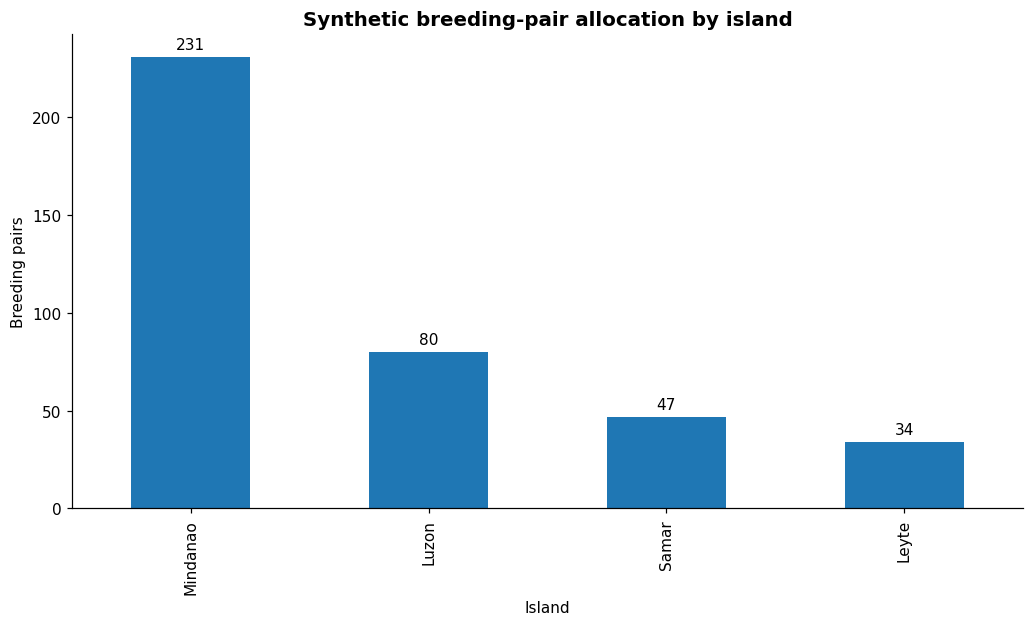

In [8]:
plt.figure()
# Figure 1: pair allocation
pair_counts=territories.island.value_counts().reindex(['Mindanao','Luzon','Samar','Leyte'])
ax=pair_counts.plot(kind='bar')
ax.set(title='Synthetic breeding-pair allocation by island',xlabel='Island',ylabel='Breeding pairs')
ax.bar_label(ax.containers[0],padding=3)
plt.tight_layout(); plt.savefig(OUT/'figure_01_pair_allocation.png',bbox_inches='tight'); plt.show(); plt.close()

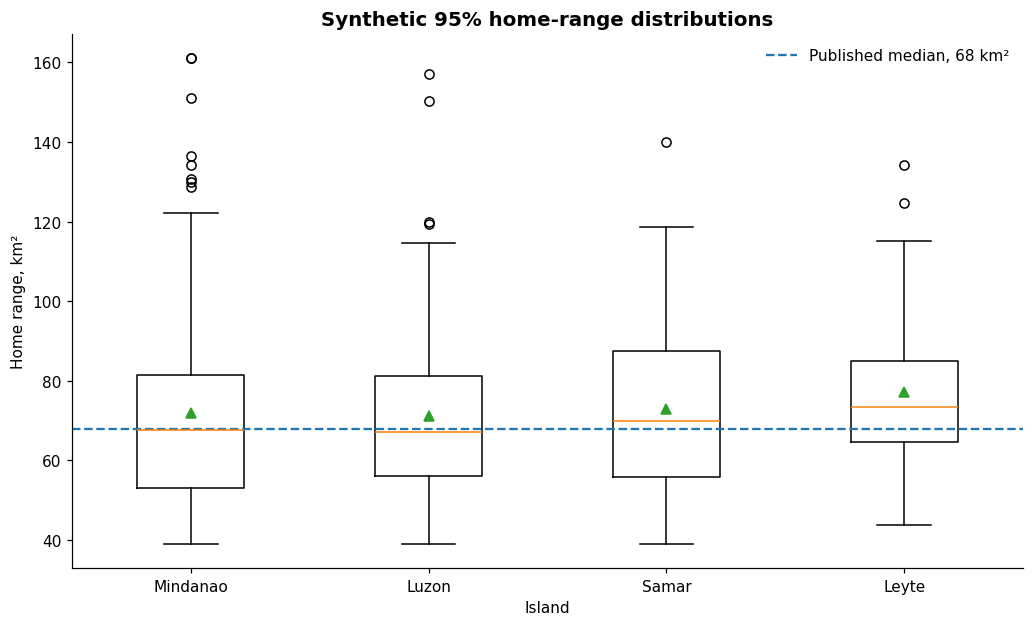

In [9]:
plt.figure()
# Figure 2: home ranges
order=['Mindanao','Luzon','Samar','Leyte']
plt.boxplot([territories.loc[territories.island==x,'home_range_95_km2'] for x in order],tick_labels=order,showmeans=True)
plt.axhline(68,linestyle='--',label='Published median, 68 km²')
plt.title('Synthetic 95% home-range distributions'); plt.xlabel('Island'); plt.ylabel('Home range, km²'); plt.legend()
plt.tight_layout(); plt.savefig(OUT/'figure_02_home_ranges.png',bbox_inches='tight'); plt.show(); plt.close()

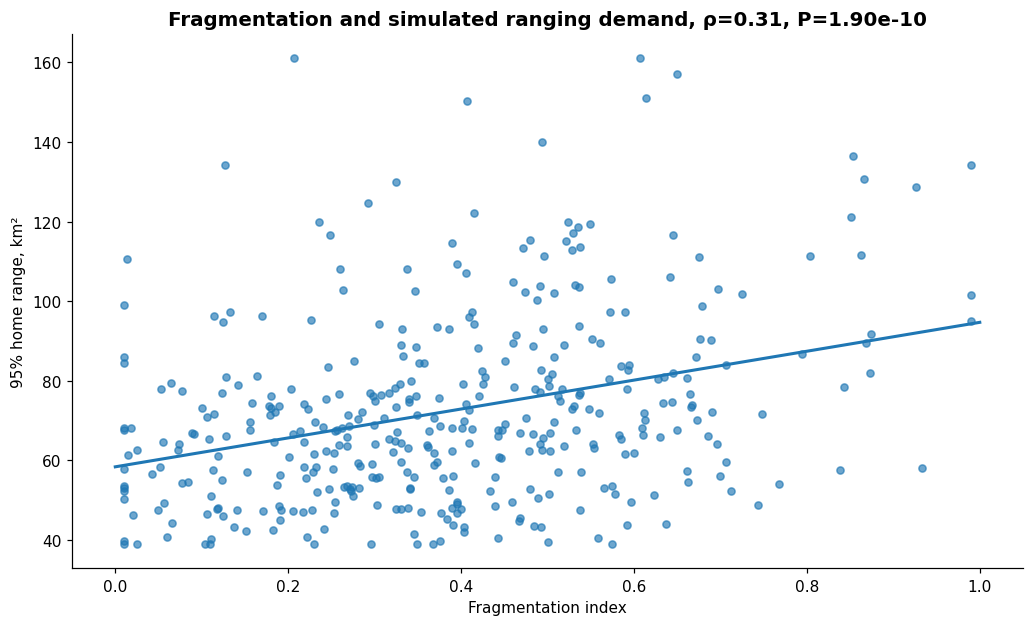

In [10]:
plt.figure()
# Figure 3: fragmentation versus home range
rho,p=spearmanr(territories.fragmentation_index,territories.home_range_95_km2)
plt.scatter(territories.fragmentation_index,territories.home_range_95_km2,s=22,alpha=0.65)
fit=np.polyfit(territories.fragmentation_index,territories.home_range_95_km2,1); xx=np.linspace(0,1,100)
plt.plot(xx,np.polyval(fit,xx),linewidth=2)
plt.title(f'Fragmentation and simulated ranging demand, ρ={rho:.2f}, P={p:.2e}')
plt.xlabel('Fragmentation index'); plt.ylabel('95% home range, km²')
plt.tight_layout(); plt.savefig(OUT/'figure_03_fragmentation_home_range.png',bbox_inches='tight'); plt.show(); plt.close()

<Figure size 1045x638 with 0 Axes>

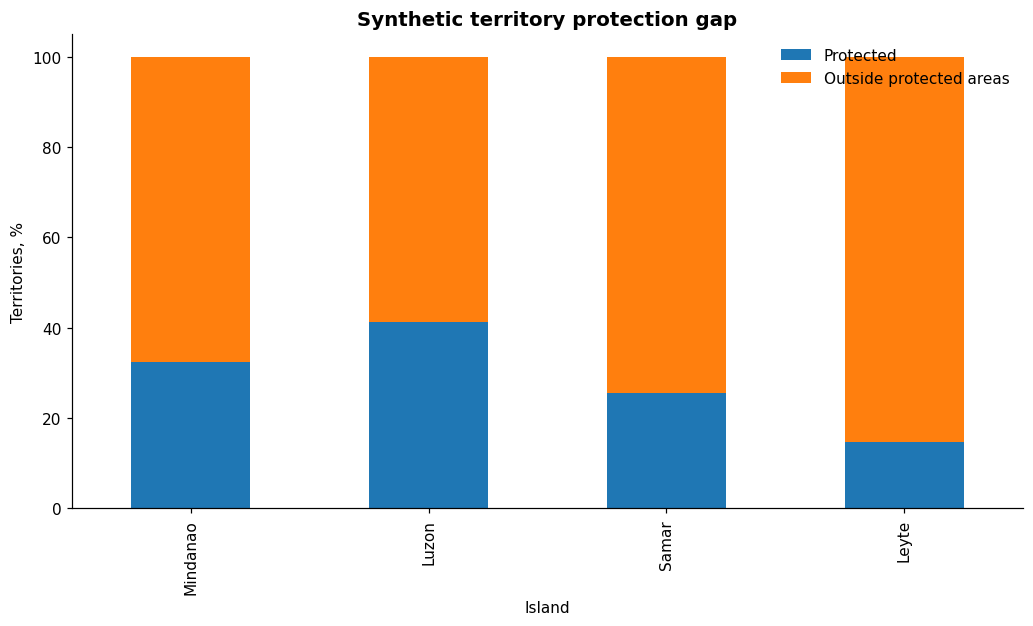

In [11]:
plt.figure()
# Figure 4: protection gap
protect=territories.groupby('island').protected.mean().mul(100).reindex(order).to_frame('Protected')
protect['Outside protected areas']=100-protect.Protected
protect.plot(kind='bar',stacked=True)
plt.title('Synthetic territory protection gap'); plt.xlabel('Island'); plt.ylabel('Territories, %')
plt.tight_layout(); plt.savefig(OUT/'figure_04_protection_gap.png',bbox_inches='tight'); plt.show(); plt.close()

### Interpretation

The model reproduces the published movement centres while retaining broad variation. Fragmentation is deliberately coupled to larger ranging demand: when prey and continuous canopy decline, an adult must search a wider area to obtain food. This creates a plausible exposure feedback, because larger movements increase contact with roads, farms, settlements, and persecution hazards. It is a mechanistic hypothesis, not an empirical causal estimate.

The 79% outside-core benchmark shows why protecting only the nest tree is inadequate. Effective conservation must include buffers, foraging habitat, corridors, and community stewardship outside formal protected areas.

## 3. Synthetic breeding histories and reproductive-risk model

Each territory is evaluated every two years from 2010–2026. Active attempts contain one egg. Incubation duration and the female share of incubation are calibrated to the published behavioural study; hatching and fledging probabilities are simulated from habitat, pressure, prey, persecution, and climate anomaly.

In [14]:
breed=[]
for _,t in territories.iterrows():
    pair_quality=rng.normal(0,0.40)
    for year in range(2010,2027,2):
        climate=rng.normal(0,0.55)
        attempted=rng.binomial(1,expit(1.35+0.55*t.forest_integrity+0.40*t.prey_index-0.55*t.human_pressure+0.2*pair_quality))
        incubation=np.clip(rng.normal(58,2.1),51,65) if attempted else np.nan
        female_share=100*np.clip(rng.beta(18.5,6.5),0.55,0.92) if attempted else np.nan
        hp=expit(0.25+1.2*t.forest_integrity+0.65*t.prey_index-1.0*t.human_pressure-0.7*t.persecution_risk-0.3*abs(climate)) if attempted else 0
        hatched=rng.binomial(1,hp) if attempted else 0
        fp=expit(0.05+1.3*t.canopy_integrity+0.9*t.prey_index-1.1*t.human_pressure-0.85*t.persecution_risk-0.4*abs(climate)+0.25*pair_quality) if hatched else 0
        fledged=rng.binomial(1,fp) if hatched else 0
        breed.append([t.territory_id,t.island,year,attempted,attempted,incubation,female_share,hatched,fledged,climate,t.forest_integrity,t.fragmentation_index,t.human_pressure,t.canopy_integrity,t.prey_index,t.persecution_risk,int(t.protected),t.risk_score])
breeding=pd.DataFrame(breed,columns=['territory_id','island','year','attempted','egg_count','incubation_days','female_incubation_share_pct','hatched','fledged','climate_anomaly','forest_integrity','fragmentation_index','human_pressure','canopy_integrity','prey_index','persecution_risk','protected','risk_score'])
active=breeding.query('attempted==1').copy()
display(pd.DataFrame({
    'metric':['Active attempts','Eggs per attempt','Mean incubation, days','Mean female incubation, %','Hatching success, %','Fledging per attempt, %'],
    'value':[len(active),active.egg_count.mean(),active.incubation_days.mean(),active.female_incubation_share_pct.mean(),100*active.hatched.mean(),100*active.fledged.mean()]
}).round(3))

,metric,value
0,Active attempts,2950.000
1,Eggs per attempt,1.000
2,"Mean incubation, days",58.006
3,"Mean female incubation, %",74.061
4,"Hatching success, %",62.373
5,"Fledging per attempt, %",37.932


<Figure size 1045x638 with 0 Axes>

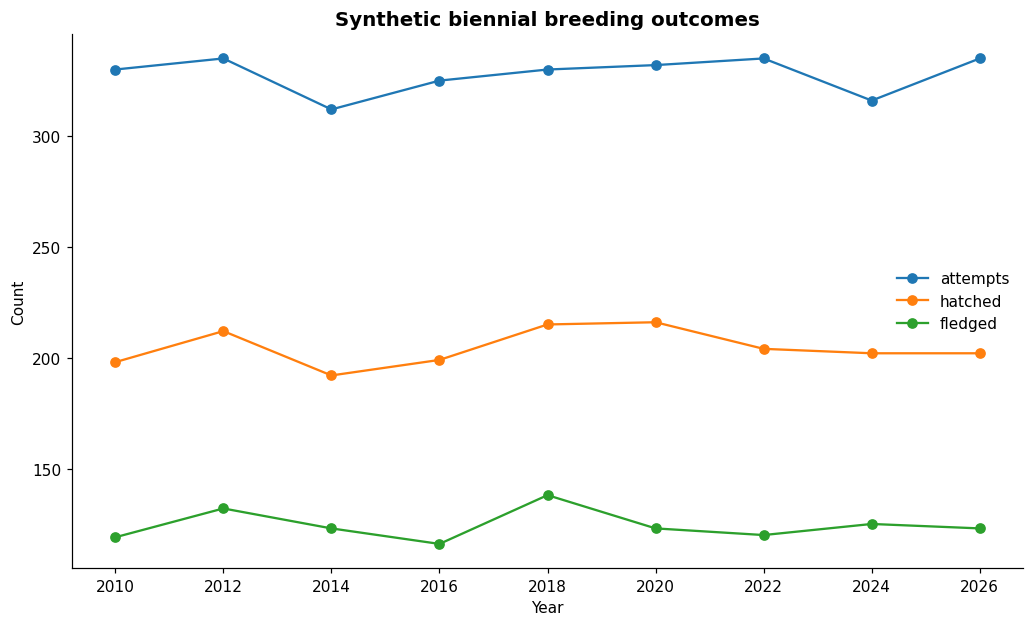

In [15]:
plt.figure()
# Figure 5: breeding outcomes over time
annual=breeding.groupby('year').agg(attempts=('attempted','sum'),hatched=('hatched','sum'),fledged=('fledged','sum'))
annual.plot(marker='o')
plt.title('Synthetic biennial breeding outcomes'); plt.xlabel('Year'); plt.ylabel('Count')
plt.tight_layout(); plt.savefig(OUT/'figure_05_breeding_outcomes.png',bbox_inches='tight'); plt.show(); plt.close()

In [16]:
# Logistic model for fledging among active attempts
features=['forest_integrity','fragmentation_index','human_pressure','canopy_integrity','prey_index','persecution_risk','protected','climate_anomaly','island']
X=active[features]; y=active.fledged
Xtr,Xte,ytr,yte=train_test_split(X,y,test_size=0.25,stratify=y,random_state=SEED)
num=[x for x in features if x!='island']
prep=ColumnTransformer([('num',StandardScaler(),num),('cat',OneHotEncoder(drop='first',handle_unknown='ignore'),['island'])])
model=Pipeline([('prep',prep),('logit',LogisticRegression(max_iter=1500,class_weight='balanced',random_state=SEED))])
model.fit(Xtr,ytr); prob=model.predict_proba(Xte)[:,1]
auc=roc_auc_score(yte,prob); brier=brier_score_loss(yte,prob)
cv=StratifiedKFold(5,shuffle=True,random_state=SEED)
cv_auc=cross_val_score(model,X,y,cv=cv,scoring='roc_auc',n_jobs=1)
print(f'Test ROC-AUC: {auc:.3f}; Brier score: {brier:.3f}; 5-fold CV AUC: {cv_auc.mean():.3f} ± {cv_auc.std():.3f}')

Test ROC-AUC: 0.674; Brier score: 0.225; 5-fold CV AUC: 0.656 ± 0.017


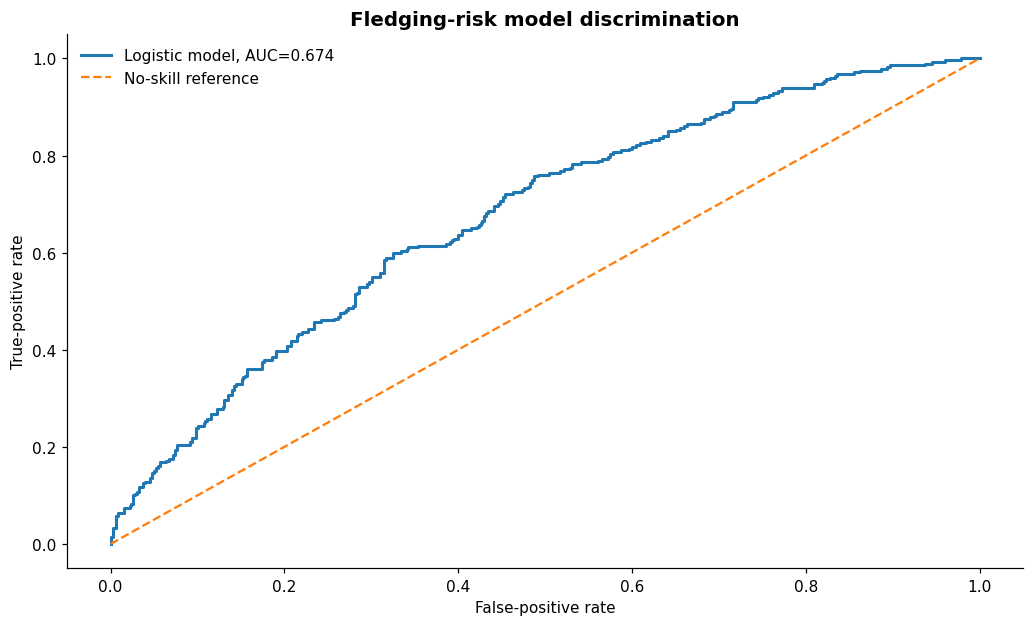

In [17]:
plt.figure()
# Figure 6: ROC curve
fpr,tpr,_=roc_curve(yte,prob)
plt.plot(fpr,tpr,linewidth=2,label=f'Logistic model, AUC={auc:.3f}')
plt.plot([0,1],[0,1],linestyle='--',label='No-skill reference')
plt.title('Fledging-risk model discrimination'); plt.xlabel('False-positive rate'); plt.ylabel('True-positive rate'); plt.legend()
plt.tight_layout(); plt.savefig(OUT/'figure_06_fledging_roc.png',bbox_inches='tight'); plt.show(); plt.close()

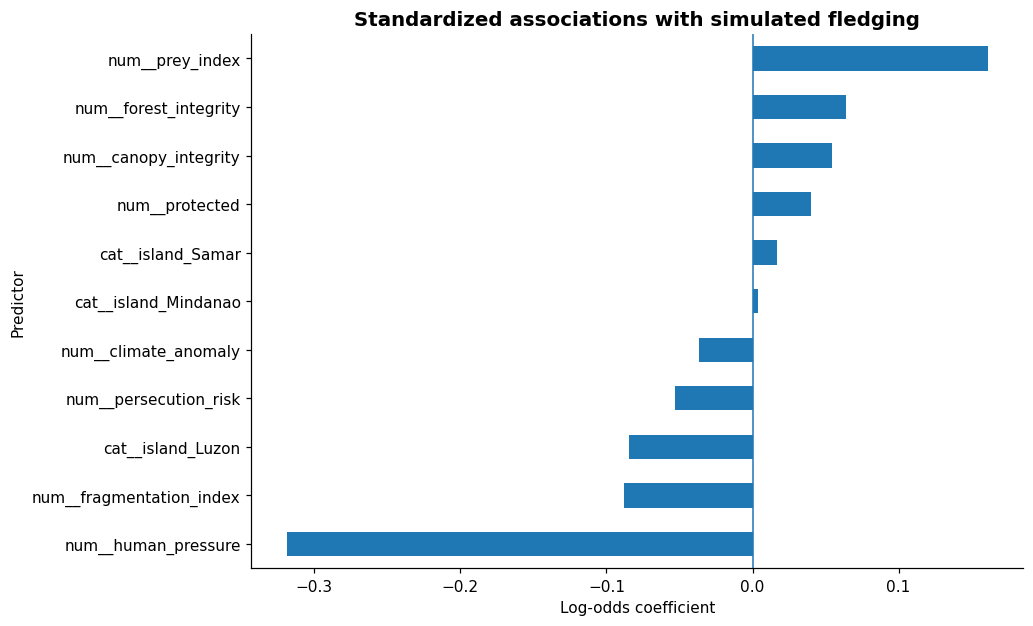

In [18]:
plt.figure()
# Figure 7: standardized model coefficients
names=model.named_steps.prep.get_feature_names_out(); coefs=pd.Series(model.named_steps.logit.coef_[0],index=names).sort_values()
coefs.plot(kind='barh'); plt.axvline(0,linewidth=1)
plt.title('Standardized associations with simulated fledging'); plt.xlabel('Log-odds coefficient'); plt.ylabel('Predictor')
plt.tight_layout(); plt.savefig(OUT/'figure_07_fledging_coefficients.png',bbox_inches='tight'); plt.show(); plt.close()

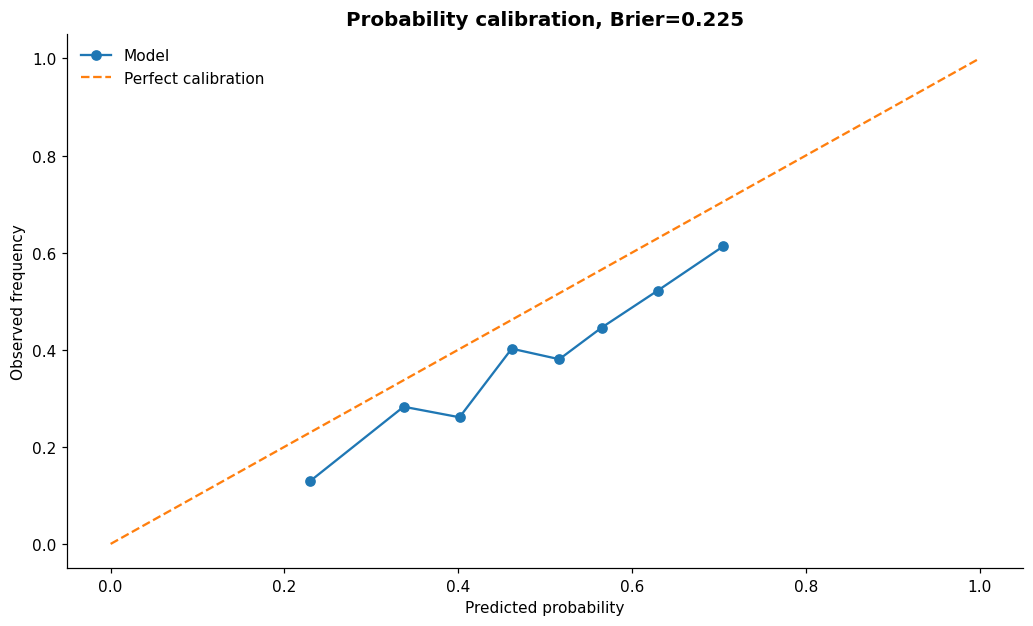

In [19]:
plt.figure()
# Figure 8: calibration
obs,pred=calibration_curve(yte,prob,n_bins=8,strategy='quantile')
plt.plot(pred,obs,marker='o',label='Model'); plt.plot([0,1],[0,1],linestyle='--',label='Perfect calibration')
plt.title(f'Probability calibration, Brier={brier:.3f}'); plt.xlabel('Predicted probability'); plt.ylabel('Observed frequency'); plt.legend()
plt.tight_layout(); plt.savefig(OUT/'figure_08_calibration.png',bbox_inches='tight'); plt.show(); plt.close()

The model should recover the rules used to create the data: canopy integrity and prey support fledging, while human pressure, persecution, and adverse climate anomalies reduce success. Recovery of those associations validates the workflow, not the effect sizes. Applied to field data, observer effort, nest detection, missingness, and temporal dependence would also need explicit modelling.

## 4. Forest-loss exposure and scenario projection

The Daipan benchmark corresponds to about 0.316% annual loss from a 4.5-million-ha baseline. Territory-specific rates vary around that value as a function of simulated pressure and fragmentation.

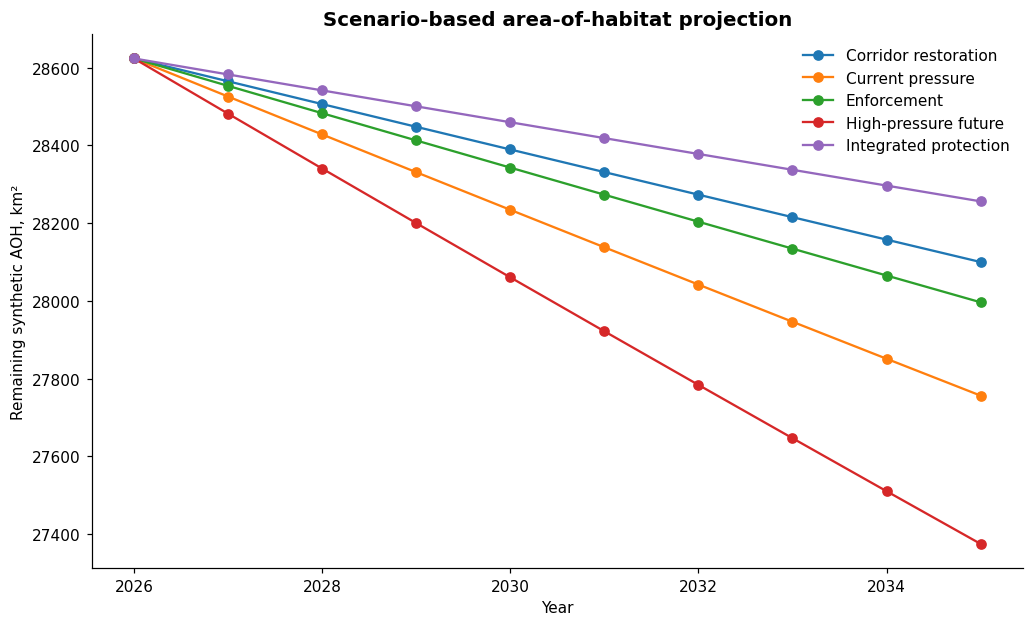

In [22]:
plt.figure()
base_loss=14213/4_500_000
territories['annual_forest_loss_rate']=np.clip(base_loss*np.exp(1.15*(territories.human_pressure-territories.human_pressure.mean())+0.70*(territories.fragmentation_index-territories.fragmentation_index.mean())+rng.normal(0,0.22,len(territories))),0.0002,0.018)
forest_scenarios={'Current pressure':1.0,'Enforcement':0.72,'Corridor restoration':0.60,'Integrated protection':0.42,'High-pressure future':1.45}
rows=[]
for name,mult in forest_scenarios.items():
    for year in range(2026,2036):
        rem=territories.territory_aoh_km2*(1-territories.annual_forest_loss_rate*mult)**(year-2026)
        rows.append([name,year,rem.sum(),territories.territory_aoh_km2.sum()-rem.sum()])
forest_projection=pd.DataFrame(rows,columns=['scenario','year','remaining_aoh_km2','loss_from_2026_km2'])
for name,g in forest_projection.groupby('scenario'):
    plt.plot(g.year,g.remaining_aoh_km2,marker='o',label=name)
plt.title('Scenario-based area-of-habitat projection'); plt.xlabel('Year'); plt.ylabel('Remaining synthetic AOH, km²'); plt.legend()
plt.tight_layout(); plt.savefig(OUT/'figure_09_aoh_projection.png',bbox_inches='tight'); plt.show(); plt.close()

## 5. Stochastic female-based population viability analysis

This is a scenario model, not a fitted demographic estimate. It starts with 392 adult females, tracks four pre-breeding age classes, and uses explicit assumed survival, breeding, and nest-success rates. The comparison is more informative than any single absolute probability.

In [24]:
scenario_table=pd.DataFrame([
 ['Current pressure',0.935,0.52,0.52,0.70],
 ['Habitat protection',0.944,0.55,0.54,0.72],
 ['Anti-persecution',0.951,0.54,0.53,0.73],
 ['Integrated conservation',0.958,0.59,0.58,0.76],
 ['High-pressure future',0.915,0.46,0.46,0.66]
],columns=['scenario','adult_survival','breeding_fraction','nest_success','prebreeder_survival'])
display(scenario_table)

def run_pva(row,reps=250,years=40):
    lrng=np.random.default_rng(SEED+int(row.adult_survival*10000))
    adults=np.full(reps,392,dtype=int); juv=np.zeros((4,reps),dtype=int); rec=np.zeros((years+1,reps),dtype=int); rec[0]=adults
    for yr in range(1,years+1):
        survivors=lrng.binomial(adults,row.adult_survival)
        breeders=lrng.binomial(adults,row.breeding_fraction)
        fledged=lrng.binomial(breeders,row.nest_success)
        female_chicks=lrng.binomial(fledged,0.5)
        recruits=lrng.binomial(juv[-1],row.prebreeder_survival)
        new=np.zeros_like(juv); new[0]=female_chicks
        for a in range(1,4): new[a]=lrng.binomial(juv[a-1],row.prebreeder_survival)
        adults=survivors+recruits; juv=new; rec[yr]=adults
    return rec

pva={}; summary=[]; long=[]
for _,s in scenario_table.iterrows():
    rec=run_pva(s); pva[s.scenario]=rec; final=rec[-1]
    summary.append([s.scenario,np.median(final),np.percentile(final,2.5),np.percentile(final,97.5),100*(rec<50).any(axis=0).mean(),100*(rec==0).any(axis=0).mean()])
    for k,year in enumerate(range(2026,2067)):
        long.append([s.scenario,year,np.median(rec[k]),np.percentile(rec[k],10),np.percentile(rec[k],90)])
pva_summary=pd.DataFrame(summary,columns=['scenario','median_adult_females_y40','lower95','upper95','prob_below50_pct','prob_zero_pct'])
pva_long=pd.DataFrame(long,columns=['scenario','year','median','p10','p90'])
display(pva_summary.round(2))

,scenario,adult_survival,breeding_fraction,nest_success,prebreeder_survival
0,Current pressure,0.935,0.52,0.52,0.70
1,Habitat protection,0.944,0.55,0.54,0.72
2,Anti-persecution,0.951,0.54,0.53,0.73
3,Integrated conservation,0.958,0.59,0.58,0.76
4,High-pressure future,0.915,0.46,0.46,0.66


,scenario,median_adult_females_y40,lower95,upper95,prob_below50_pct,prob_zero_pct
0,Current pressure,106.0,83.00,132.78,0.0,0.0
1,Habitat protection,191.0,155.22,239.78,0.0,0.0
2,Anti-persecution,249.0,205.22,302.33,0.0,0.0
3,Integrated conservation,526.0,437.15,603.55,0.0,0.0
4,High-pressure future,30.0,17.45,45.55,99.6,0.0


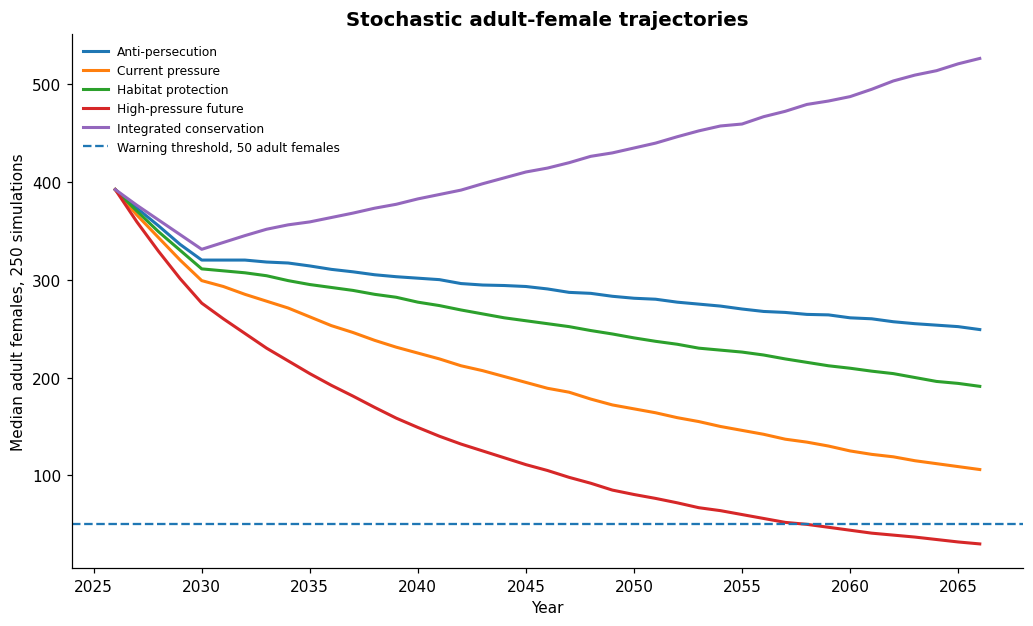

In [25]:
plt.figure()
# Figure 10: PVA trajectories
for name,g in pva_long.groupby('scenario'):
    plt.plot(g.year,g['median'],linewidth=2,label=name)
plt.axhline(50,linestyle='--',label='Warning threshold, 50 adult females')
plt.title('Stochastic adult-female trajectories'); plt.xlabel('Year'); plt.ylabel('Median adult females, 250 simulations'); plt.legend(fontsize=8)
plt.tight_layout(); plt.savefig(OUT/'figure_10_pva_trajectories.png',bbox_inches='tight'); plt.show(); plt.close()

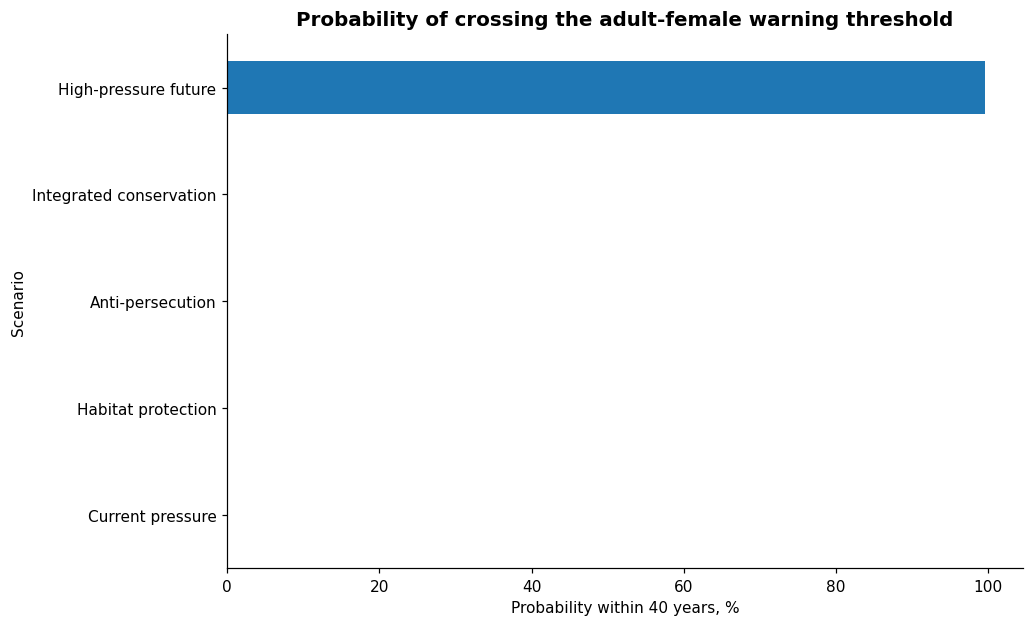

In [26]:
plt.figure()
# Figure 11: threshold risk
pva_summary.set_index('scenario').prob_below50_pct.sort_values().plot(kind='barh')
plt.title('Probability of crossing the adult-female warning threshold'); plt.xlabel('Probability within 40 years, %'); plt.ylabel('Scenario')
plt.tight_layout(); plt.savefig(OUT/'figure_11_pva_risk.png',bbox_inches='tight'); plt.show(); plt.close()

Small changes in adult survival can strongly affect a slow-breeding raptor. This is why anti-persecution and rapid response to injured adults can be demographically powerful. Habitat protection remains essential because it supports prey, nesting success, recruitment, and movement connectivity. The integrated scenario tests the principle that adult survival and habitat quality are complementary rather than interchangeable.

## 6. Synthetic conservation genomics and pairing optimisation

The nuclear dataset is calibrated to a mean genome-wide heterozygosity of 0.000309 and minimum of 0.000207 in 35 synthetic individuals. The mitochondrial dataset contains 32 synthetic individuals and 17 haplotypes, with mean nucleotide-diversity proxy 0.00054. No real sequences are simulated.

In [29]:
# Nuclear diversity
n=35
h=rng.lognormal(np.log(0.00031),0.18,n)
h=0.000207+(h-h.min())/(h.mean()-h.min())*(0.000309-0.000207)
h[0]=0.000207; h[-1]+=n*(0.000309-h.mean())
genomic=pd.DataFrame({
 'individual_id':[f'GE-{i+1:02d}' for i in range(n)],
 'island':rng.choice(order,n,p=[0.59,0.20,0.12,0.09]),
 'sex':['Female']*18+['Male']*17,
 'heterozygosity':h,
 'ROH_fraction_proxy':np.clip(0.52-900*h+rng.normal(0,0.025,n),0.10,0.45),
 'kinship_axis_1':rng.normal(0,1,n),'kinship_axis_2':rng.normal(0,1,n)
})

# Mitochondrial diversity
haps=[f'H{i+1:02d}' for i in range(17)]; counts=np.array([5,4,3,3,2,2,2,2]+[1]*9); assert counts.sum()==32
assign=np.repeat(haps,counts); rng.shuffle(assign)
mito=pd.DataFrame({'individual_id':[f'MT-{i+1:02d}' for i in range(32)],'island':rng.choice(order,32,p=[0.59,0.20,0.12,0.09]),'haplotype':assign,'pi_proxy':np.clip(rng.normal(0.00054,0.00025,32),0.00003,0.0013)})
mito.pi_proxy*=0.00054/mito.pi_proxy.mean()
freq=mito.haplotype.value_counts()/len(mito); hap_div=len(mito)/(len(mito)-1)*(1-(freq**2).sum())

display(pd.DataFrame([
 ['Nuclear n',35,len(genomic)],['Mean heterozygosity',0.000309,genomic.heterozygosity.mean()],['Minimum heterozygosity',0.000207,genomic.heterozygosity.min()],
 ['Mitochondrial n',32,len(mito)],['Haplotypes',17,mito.haplotype.nunique()],['Mean π proxy',0.00054,mito.pi_proxy.mean()],['Haplotype diversity',np.nan,hap_div]
],columns=['metric','published_target','synthetic_value']).round(7))

,metric,published_target,synthetic_value
0,Nuclear n,35.000000,35.000000
1,Mean heterozygosity,0.000309,0.000309
2,Minimum heterozygosity,0.000207,0.000207
3,Mitochondrial n,32.000000,32.000000
4,Haplotypes,17.000000,17.000000
5,Mean π proxy,0.000540,0.000540
6,Haplotype diversity,NaN,0.947581


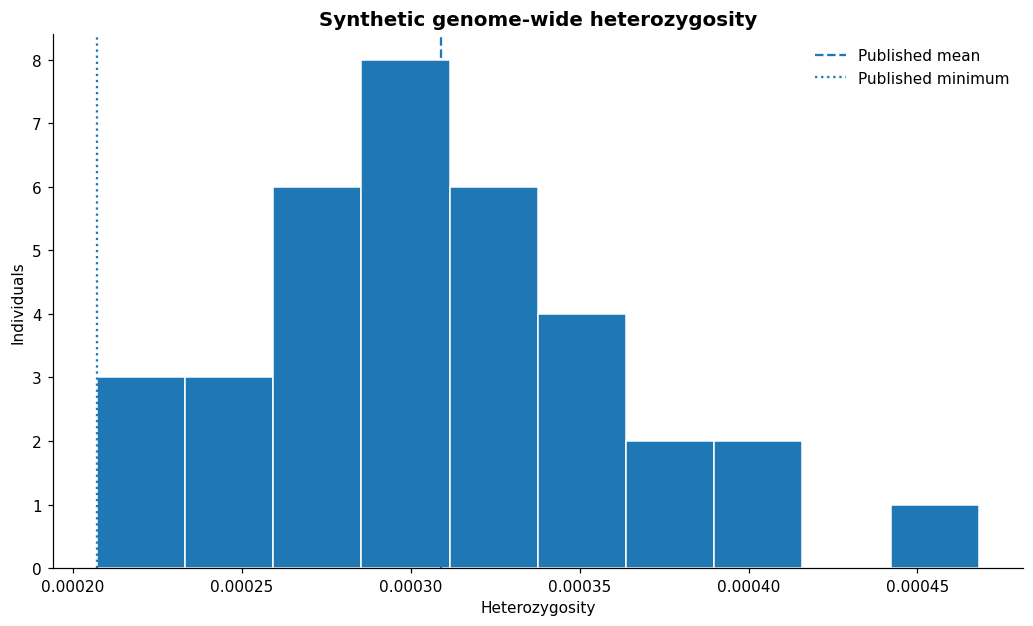

In [30]:
plt.figure()
# Figure 12: nuclear heterozygosity
plt.hist(genomic.heterozygosity,bins=10,edgecolor='white')
plt.axvline(0.000309,linestyle='--',label='Published mean'); plt.axvline(0.000207,linestyle=':',label='Published minimum')
plt.title('Synthetic genome-wide heterozygosity'); plt.xlabel('Heterozygosity'); plt.ylabel('Individuals'); plt.legend()
plt.tight_layout(); plt.savefig(OUT/'figure_12_heterozygosity.png',bbox_inches='tight'); plt.show(); plt.close()

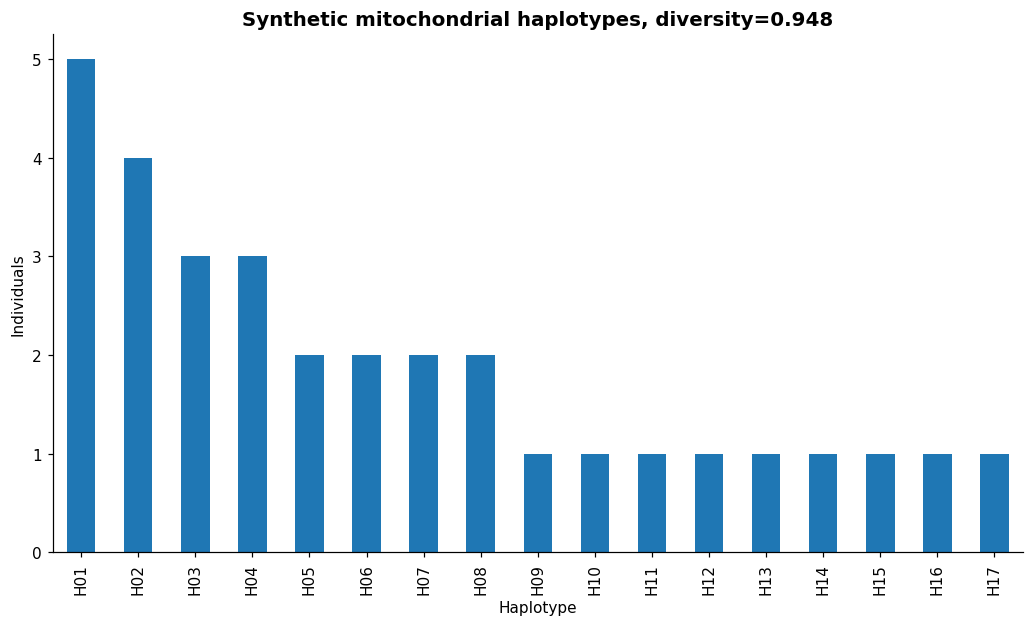

In [31]:
plt.figure()
# Figure 13: haplotypes
mito.haplotype.value_counts().sort_index().plot(kind='bar')
plt.title(f'Synthetic mitochondrial haplotypes, diversity={hap_div:.3f}'); plt.xlabel('Haplotype'); plt.ylabel('Individuals')
plt.tight_layout(); plt.savefig(OUT/'figure_13_haplotypes.png',bbox_inches='tight'); plt.show(); plt.close()

Optimised mean score=1.983; random mean=1.600; gain=23.9%


,female_id,male_id,female_island,male_island,pair_score
14,GE-16,GE-35,Samar,Mindanao,3.042869
0,GE-02,GE-34,Luzon,Mindanao,2.527779
9,GE-11,GE-31,Mindanao,Luzon,2.421789
15,GE-17,GE-25,Mindanao,Luzon,2.271491
6,GE-08,GE-28,Samar,Mindanao,2.175837
13,GE-15,GE-23,Mindanao,Luzon,2.052390
11,GE-13,GE-33,Samar,Mindanao,2.012438
16,GE-18,GE-27,Mindanao,Mindanao,1.991008
3,GE-05,GE-19,Leyte,Mindanao,1.962410
12,GE-14,GE-22,Luzon,Mindanao,1.950212


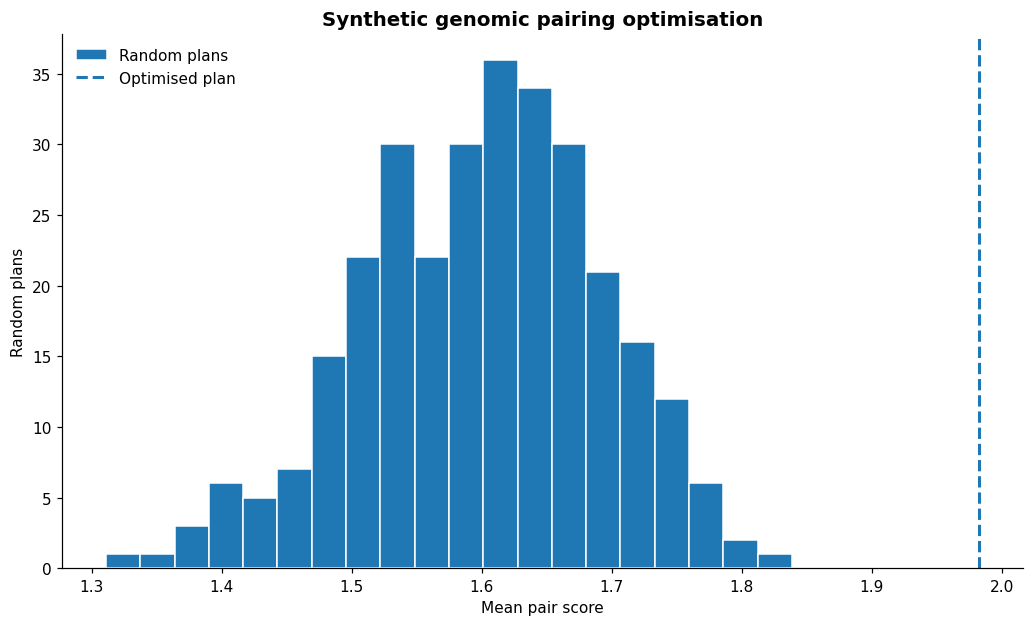

In [32]:
plt.figure()
# Pairing optimisation teaching example
f=genomic.query("sex=='Female'").reset_index(drop=True); m=genomic.query("sex=='Male'").reset_index(drop=True)
score=np.zeros((len(f),len(m)))
for i,fr in f.iterrows():
    for j,mr in m.iterrows():
        dist=np.hypot(fr.kinship_axis_1-mr.kinship_axis_1,fr.kinship_axis_2-mr.kinship_axis_2)
        lineage=0.12 if fr.island!=mr.island else 0
        diversity=900*(fr.heterozygosity+mr.heterozygosity)
        score[i,j]=0.6*dist+lineage+diversity
ri,ci=linear_sum_assignment(-score); optimal=score[ri,ci]
random_means=[]
for _ in range(300): random_means.append(score[ri,rng.permutation(len(m))[:len(ri)]].mean())
random_means=np.array(random_means); gain=100*(optimal.mean()/random_means.mean()-1)
optimal_pairs=pd.DataFrame({'female_id':f.loc[ri,'individual_id'].to_numpy(),'male_id':m.loc[ci,'individual_id'].to_numpy(),'female_island':f.loc[ri,'island'].to_numpy(),'male_island':m.loc[ci,'island'].to_numpy(),'pair_score':optimal}).sort_values('pair_score',ascending=False)
print(f'Optimised mean score={optimal.mean():.3f}; random mean={random_means.mean():.3f}; gain={gain:.1f}%')
display(optimal_pairs.head(10))
plt.hist(random_means,bins=20,edgecolor='white',label='Random plans'); plt.axvline(optimal.mean(),linestyle='--',linewidth=2,label='Optimised plan')
plt.title('Synthetic genomic pairing optimisation'); plt.xlabel('Mean pair score'); plt.ylabel('Random plans'); plt.legend()
plt.tight_layout(); plt.savefig(OUT/'figure_14_pairing_optimisation.png',bbox_inches='tight'); plt.show(); plt.close()

Low nuclear heterozygosity and historical bottlenecks raise concern about inbreeding and adaptive capacity. The presence of multiple mitochondrial haplotypes shows that distinct maternal lineages remain available to conserve. These are complementary observations. Real pairing decisions require validated pedigrees or genomic relatedness, veterinary fitness, behavioural compatibility, welfare review, and demographic representation.

## 7. Conservation archetypes and intervention portfolio

,n,forest,fragmentation,pressure,prey,persecution,protected_pct,median_risk,archetype
cluster,,,,,,,,,
3,119,0.773,0.201,0.279,0.716,0.234,57.143,19.800,Relatively secure forest
0,105,0.706,0.290,0.521,0.576,0.404,33.333,38.474,Watch-list landscape
2,103,0.472,0.555,0.398,0.464,0.377,17.476,48.779,Fragmented pressure front
1,65,0.431,0.597,0.741,0.370,0.600,6.154,65.166,Critical intervention zone


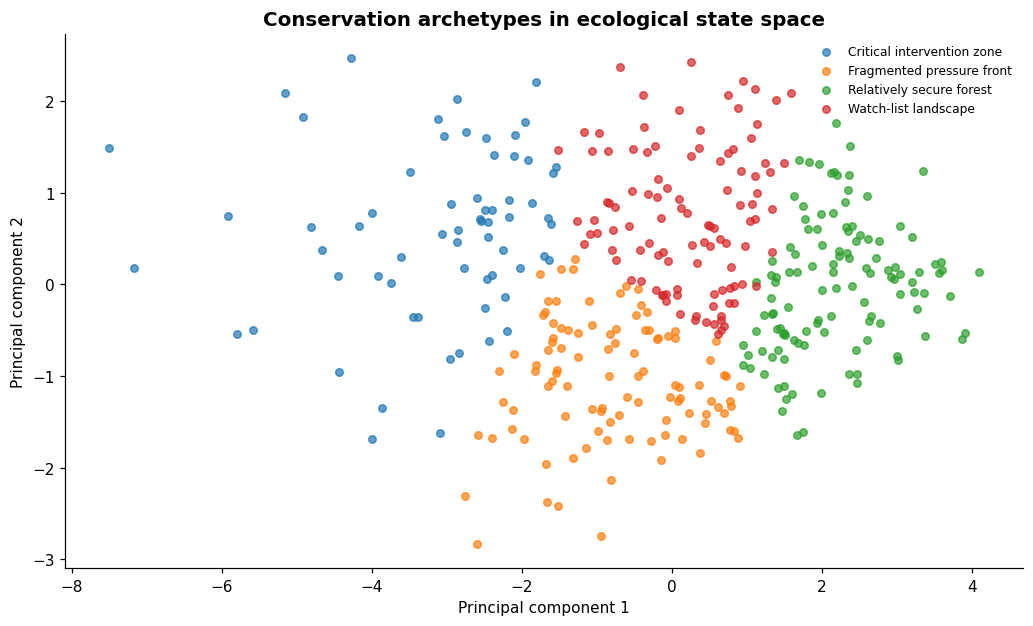

In [35]:
plt.figure()
cluster_vars=['forest_integrity','fragmentation_index','human_pressure','prey_index','persecution_risk','annual_forest_loss_rate']
Z=StandardScaler().fit_transform(territories[cluster_vars]); km=KMeans(4,n_init=20,random_state=SEED); territories['cluster']=km.fit_predict(Z)
profiles=territories.groupby('cluster').agg(n=('territory_id','size'),forest=('forest_integrity','mean'),fragmentation=('fragmentation_index','mean'),pressure=('human_pressure','mean'),prey=('prey_index','mean'),persecution=('persecution_risk','mean'),protected_pct=('protected',lambda x:100*x.mean()),median_risk=('risk_score','median')).sort_values('median_risk')
label_map={profiles.index[0]:'Relatively secure forest',profiles.index[1]:'Watch-list landscape',profiles.index[2]:'Fragmented pressure front',profiles.index[3]:'Critical intervention zone'}
territories['archetype']=territories.cluster.map(label_map); profiles['archetype']=profiles.index.map(label_map)
display(profiles.round(3))

pc=PCA(2,random_state=SEED).fit_transform(Z); territories['PC1']=pc[:,0]; territories['PC2']=pc[:,1]
for name,g in territories.groupby('archetype'): plt.scatter(g.PC1,g.PC2,s=24,alpha=0.7,label=name)
plt.title('Conservation archetypes in ecological state space'); plt.xlabel('Principal component 1'); plt.ylabel('Principal component 2'); plt.legend(fontsize=8)
plt.tight_layout(); plt.savefig(OUT/'figure_15_archetypes.png',bbox_inches='tight'); plt.show(); plt.close()

,territories,cost,benefit
recommended_action,,,
Community patrol and anti-persecution,61,183.0,1245.63
Corridor restoration,9,45.0,184.57
Stewardship or protected-area agreement,8,36.0,137.19
Prey and habitat recovery,8,32.0,125.53


Funded 86 territories with 296.0/300 cost units


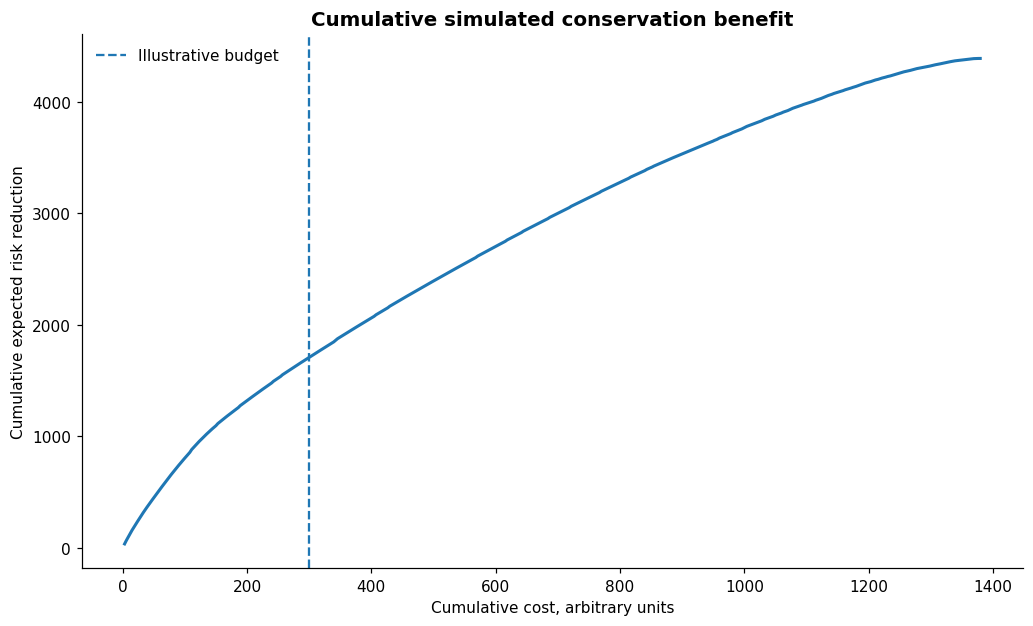

In [36]:
plt.figure()
def action(r):
    if r.persecution_risk>0.62 or r.distance_to_road_km<3: return 'Community patrol and anti-persecution'
    if r.fragmentation_index>0.55: return 'Corridor restoration'
    if r.prey_index<0.45: return 'Prey and habitat recovery'
    if not r.protected: return 'Stewardship or protected-area agreement'
    return 'Long-term monitoring'
territories['recommended_action']=territories.apply(action,axis=1)
cost={'Community patrol and anti-persecution':3.0,'Corridor restoration':5.0,'Prey and habitat recovery':4.0,'Stewardship or protected-area agreement':4.5,'Long-term monitoring':1.5}
effect={'Community patrol and anti-persecution':0.34,'Corridor restoration':0.27,'Prey and habitat recovery':0.24,'Stewardship or protected-area agreement':0.30,'Long-term monitoring':0.10}
territories['cost_units']=territories.recommended_action.map(cost); territories['expected_risk_reduction']=territories.recommended_action.map(effect)*territories.risk_score
territories['benefit_cost']=territories.expected_risk_reduction/territories.cost_units*(1+0.35*(~territories.protected))
ranked=territories.sort_values('benefit_cost',ascending=False).copy(); ranked['cumulative_cost']=ranked.cost_units.cumsum(); budget=300; portfolio=ranked.query('cumulative_cost<=@budget').copy()
portfolio_summary=portfolio.groupby('recommended_action').agg(territories=('territory_id','size'),cost=('cost_units','sum'),benefit=('expected_risk_reduction','sum')).sort_values('benefit',ascending=False)
display(portfolio_summary.round(2)); print(f'Funded {len(portfolio)} territories with {portfolio.cost_units.sum():.1f}/{budget} cost units')
plt.plot(ranked.cumulative_cost,ranked.expected_risk_reduction.cumsum(),linewidth=2); plt.axvline(budget,linestyle='--',label='Illustrative budget')
plt.title('Cumulative simulated conservation benefit'); plt.xlabel('Cumulative cost, arbitrary units'); plt.ylabel('Cumulative expected risk reduction'); plt.legend()
plt.tight_layout(); plt.savefig(OUT/'figure_16_cost_effectiveness.png',bbox_inches='tight'); plt.show(); plt.close()

## 8. Integrated interpretation and implications

1. **Benchmark fidelity:** the simulation reproduces the key published central values while clearly labelling island allocations and demographic rates as assumptions.
2. **Movement beyond core areas:** a median 68-km² home range and 79% of space-time outside core areas imply that nest-centred protection alone cannot cover the full ecological needs of adults.
3. **Adult survival is pivotal:** because reproduction is slow, preventing shooting, trapping, collision, and other avoidable adult mortality can yield large demographic benefits.
4. **Habitat and mortality interact:** fragmentation can increase ranging demand and exposure, while habitat restoration can improve prey access, connectivity, and recruitment.
5. **Genetic management should be lineage-aware:** low nuclear heterozygosity argues for careful relatedness management, while multiple mitochondrial haplotypes argue against losing rare maternal lineages.
6. **Prioritisation must remain auditable:** model inputs, scenario assumptions, coefficients, and costs are visible, so stakeholders can challenge and update them.

### Empirical programme needed to replace assumptions

A national analysis should integrate verified nest occupancy and productivity, marked-bird survival, telemetry with strict location security, prey abundance, forest structure, roads and power infrastructure, persecution incidents, rescue outcomes, genomic relatedness, and observation effort. Integrated population modelling and before–after–control–impact evaluations would then allow real intervention effect sizes to replace the illustrative coefficients used here.

### Limitations

This notebook is not a census, official recovery plan, field survey, or substitute for Indigenous and local ecological knowledge. Synthetic model associations cannot be cited as biological discoveries. Their value lies in hypothesis generation, workflow validation, uncertainty communication, and identification of high-value data gaps.

## 9. Export datasets and summaries

In [39]:
territories.to_csv(OUT/'synthetic_territories.csv',index=False)
breeding.to_csv(OUT/'synthetic_breeding_histories.csv',index=False)
forest_projection.to_csv(OUT/'forest_scenario_projection.csv',index=False)
pva_summary.to_csv(OUT/'pva_scenario_summary.csv',index=False)
pva_long.to_csv(OUT/'pva_trajectory_quantiles.csv',index=False)
genomic.to_csv(OUT/'synthetic_nuclear_genomics.csv',index=False)
mito.to_csv(OUT/'synthetic_mitochondrial_haplotypes.csv',index=False)
optimal_pairs.to_csv(OUT/'synthetic_optimised_pairing_plan.csv',index=False)
portfolio.to_csv(OUT/'illustrative_intervention_portfolio.csv',index=False)
validation.to_csv(OUT/'benchmark_validation.csv',index=False)
files=pd.DataFrame({'file':sorted(p.name for p in OUT.iterdir())}); files['type']=files.file.str.rsplit('.',n=1).str[-1].str.upper(); display(files)
print(f'Created {len(files)} output files.')

,file,type
0,benchmark_validation.csv,CSV
1,figure_01_pair_allocation.png,PNG
2,figure_02_home_ranges.png,PNG
3,figure_03_fragmentation_home_range.png,PNG
4,figure_04_protection_gap.png,PNG
5,figure_05_breeding_outcomes.png,PNG
6,figure_06_fledging_roc.png,PNG
7,figure_07_fledging_coefficients.png,PNG
8,figure_08_calibration.png,PNG
9,figure_09_aoh_projection.png,PNG


Created 27 output files.


## References

Bacus, M. G., et al. (2025). Mitogenomic diversity and population structure of the Philippine eagle. *Ecology and Evolution*. https://doi.org/10.1002/ece3.72572. PMID 41356510.

Bueser, G. L. L., Bueser, K. G., Afan, D. S., Salvador, D. I., Grier, J. W., Kennedy, R. S., & Miranda, H. C. (2003). Distribution and nesting density of the Philippine eagle *Pithecophaga jefferyi* on Mindanao Island, Philippines. *Ibis, 145*, 130–135. https://doi.org/10.1046/j.1474-919X.2003.00131.x.

Daipan, B. P. O. (2021). Forest loss in terrestrial Key Biodiversity Areas in the Philippines, 2001–2019. *Journal of Threatened Taxa, 13*, 20019–20032. https://doi.org/10.11609/jott.6904.13.13.20019-20032.

Ibañez, J. C., Miranda, H. C., Balaquit-Ibañez, G., Afan, D. S., & Kennedy, R. S. (2003). Notes on the breeding behavior of a Philippine eagle pair at Mount Sinaka, Central Mindanao. *Wilson Bulletin, 115*, 333–336. https://doi.org/10.1676/01-054.

Ong, P. S., et al. (2011). DNA barcodes of Philippine accipitrids. *Molecular Ecology Resources*. https://doi.org/10.1111/j.1755-0998.2010.02928.x. PMID 21429130.

Perdon, J. P. M., et al. (2026). Genome-wide diversity and demographic history of the critically endangered Philippine eagle. *BMC Genomics*. https://doi.org/10.1186/s12864-026-12859-9. PMID 42010461.

Perez, G. J., et al. (2020). Forest-cover change in the Sierra Madre Biodiversity Corridor, Philippines. *Forests, 11*, 1071. https://doi.org/10.3390/f11101071. FAO AGRIS record.

Sutton, L. J., et al. (2023). A range-wide assessment of the Philippine eagle population and habitat. *Animal Conservation*. https://doi.org/10.1111/acv.12854.

Sutton, L. J., et al. (2024). Space-time home range and resource selection of adult Philippine eagles. *Ibis*. https://doi.org/10.1111/ibi.13233.

**Index provenance:** PubMed PMIDs are provided where verified. The Perez forest-cover paper has an FAO AGRIS record. Relevant journal titles were checked against the USDA National Agricultural Library journal-index resource used for AGRICOLA. Indexing should be rechecked on the date of formal submission.